In [41]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [42]:
load_dotenv()

True

In [43]:
model = ChatGroq(model="openai/gpt-oss-20b")

In [44]:
class ChatbotState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]
    

In [45]:
def Chatbot(state:ChatbotState)->ChatbotState:
    message = state["messages"]
    response = model.invoke(message)
    return {"messages":[response]}

In [46]:
checkpointer = MemorySaver()
graph = StateGraph(ChatbotState)
graph.add_node("Chatbot",Chatbot)

In [47]:
graph.add_edge(START,"Chatbot")
graph.add_edge("Chatbot",END)
workflow = graph.compile(checkpointer=checkpointer)

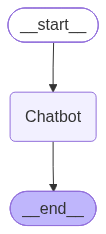

In [48]:
workflow

In [49]:
thread_id = '1'
initial_state = {
    'messages':[HumanMessage(content="what is the science behind tyres")]
}
config = {'configurable':{'thread_id':thread_id}}
result = workflow.invoke(initial_state,config=config)

In [50]:
result

{'messages': [HumanMessage(content='what is the science behind tyres', additional_kwargs={}, response_metadata={}, id='8992aa7b-88db-44e9-833a-90948fe741c0'),
  AIMessage(content='### The Science Behind Tyres – From Physics to Materials\n\nA tyre is a complex, engineered system that turns a vehicle’s mechanical energy into motion while providing safety, comfort, and performance. Below is a “tour” of the key scientific concepts that govern tyre design, manufacture, and operation.\n\n| Theme | What It Is | Why It Matters |\n|-------|------------|----------------|\n| **Pneumatic principle** | A tyre is a sealed, pressurized air chamber that acts as a compliant load‑bearing element. | The air pressure supports the vehicle’s weight and defines the contact area (the *contact patch*) that interacts with the road. |\n| **Viscoelastic rubber** | Rubber behaves both like a viscous fluid (it flows under stress) and an elastic solid (it springs back). | The hysteresis (energy lost as heat) of the 

In [51]:
while True:
    user = input("Type here:")
    print("user:"+user)
    if user.strip().lower() in ["exit","stop","end","bye"]:
        break
    response = workflow.invoke({"messages":[HumanMessage(content=user)]},config=config)
    print("AI:",response)

user:hello
AI: {'messages': [HumanMessage(content='what is the science behind tyres', additional_kwargs={}, response_metadata={}, id='8992aa7b-88db-44e9-833a-90948fe741c0'), AIMessage(content='### The Science Behind Tyres – From Physics to Materials\n\nA tyre is a complex, engineered system that turns a vehicle’s mechanical energy into motion while providing safety, comfort, and performance. Below is a “tour” of the key scientific concepts that govern tyre design, manufacture, and operation.\n\n| Theme | What It Is | Why It Matters |\n|-------|------------|----------------|\n| **Pneumatic principle** | A tyre is a sealed, pressurized air chamber that acts as a compliant load‑bearing element. | The air pressure supports the vehicle’s weight and defines the contact area (the *contact patch*) that interacts with the road. |\n| **Viscoelastic rubber** | Rubber behaves both like a viscous fluid (it flows under stress) and an elastic solid (it springs back). | The hysteresis (energy lost as 